# Flight Data Analysis
This is a mini project for data analysis of flight dataset. We will be analyzing and cleaning data with help of pandas library and making visualization with matplotlib library.

This analysis will be helpful for those working in the airline or travel domain industry.

In [1]:
# importing all the required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [2]:
# loading the data set
df = pd.read_csv("airlines_flights_data.csv")
df.head()

,index,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


## Cleaning Data

In [3]:
# Droping the index column
df.drop("index",axis=1,inplace=True)

In [4]:
# Getting some information about dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 11 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   airline           300153 non-null  object 
 1   flight            300153 non-null  object 
 2   source_city       300153 non-null  object 
 3   departure_time    300153 non-null  object 
 4   stops             300153 non-null  object 
 5   arrival_time      300153 non-null  object 
 6   destination_city  300153 non-null  object 
 7   class             300153 non-null  object 
 8   duration          300153 non-null  float64
 9   days_left         300153 non-null  int64  
 10  price             300153 non-null  int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 25.2+ MB


In [5]:
# Getting Statistical summary
df.describe()

,duration,days_left,price
count,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523
std,7.191997,13.561004,22697.767366
min,0.830000,1.000000,1105.000000
25%,6.830000,15.000000,4783.000000
50%,11.250000,26.000000,7425.000000
75%,16.170000,38.000000,42521.000000
max,49.830000,49.000000,123071.000000


In [6]:
# Getting the shape of the dataset
print(f"The dataset has rows: {df.shape[0]}")
print(f"The dataset has columns: {df.shape[1]}")

The dataset has rows: 300153
The dataset has columns: 11


In [11]:
# Checking for mising values in dataset
df.isnull().sum()

airline             0
flight              0
source_city         0
departure_time      0
stops               0
arrival_time        0
destination_city    0
class               0
duration            0
days_left           0
price               0
dtype: int64

# Exploratory Data Analysis
In this section we will be getting some insights about the dataset which will be helpful in descision making.

### Q1. What are the airlines in the dataset, accompained by their frequency?

In [12]:
# Checking number of unique airlines
unique_airline = df["airline"].nunique()
print(f"The number of unique airline is: {unique_airline}")

The number of unique airline is: 6


In [13]:
# Checking the frequency of the airlines
df["airline"].value_counts()

airline
Vistara      127859
Air_India     80892
Indigo        43120
GO_FIRST      23173
AirAsia       16098
SpiceJet       9011
Name: count, dtype: int64

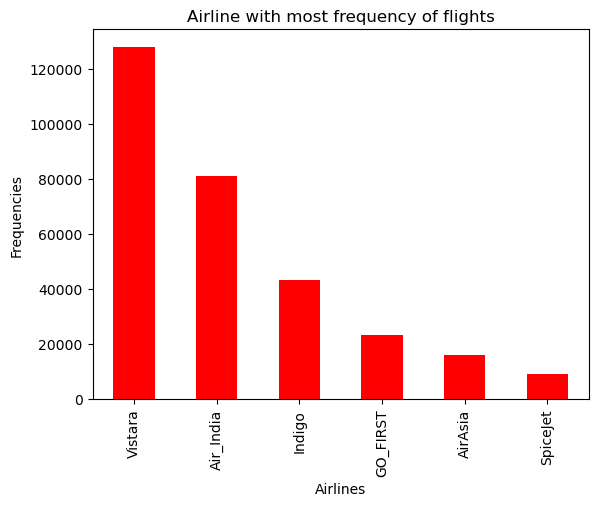

In [14]:
# Showing the frequency of the flight using a bar graph
df["airline"].value_counts(ascending=False).plot.bar(color="red")
plt.title("Airline with most frequency of flights")
plt.xlabel("Airlines")
plt.ylabel("Frequencies")
plt.show()

### Q2. Show bar graph representing the departure time and arrival time

In [39]:
# Showing all deprature time for the flights
df["departure_time"].value_counts().sort_values(ascending=False)

departure_time
Morning          71146
Early_Morning    66790
Evening          65102
Night            48015
Afternoon        47794
Late_Night        1306
Name: count, dtype: int64

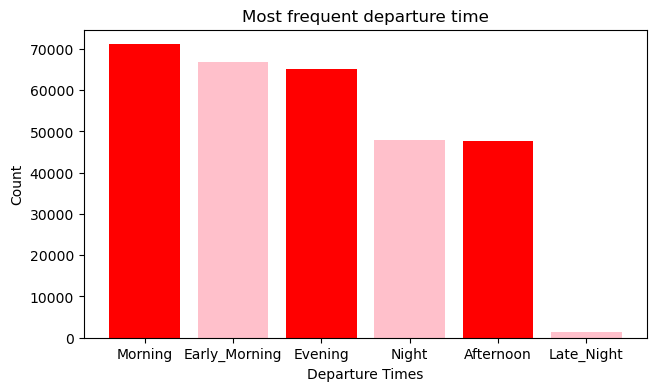

In [17]:
# showing the departure time on bar graph
plt.figure(figsize=(16,4))
plt.subplot(1,2,2)
plt.bar(df["departure_time"].value_counts().index,df["departure_time"].value_counts().values,color=["red","pink"])
plt.title("Most frequent departure time")
plt.xlabel("Departure Times")
plt.ylabel("Count")
plt.show()




In [42]:
# Showing arrival time
df["arrival_time"].value_counts().sort_values(ascending=False)

arrival_time
Night            91538
Evening          78323
Morning          62735
Afternoon        38139
Early_Morning    15417
Late_Night       14001
Name: count, dtype: int64

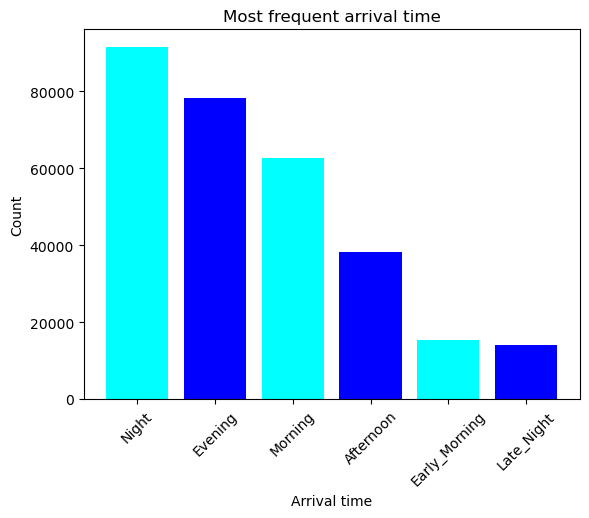

In [41]:
# Showing all arrival time frequency on bar graph

x = df["arrival_time"].value_counts().index
y = df["arrival_time"].value_counts().values
plt.bar(x,y,color=["Cyan","Blue"])
plt.title("Most frequent arrival time")
plt.xlabel("Arrival time")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()

### Q3. Show bar graph representing the source city and destination city

In [19]:
# showing count of all source city
df["source_city"].value_counts()

source_city
Delhi        61343
Mumbai       60896
Bangalore    52061
Kolkata      46347
Hyderabad    40806
Chennai      38700
Name: count, dtype: int64

In [20]:
# showing count of all destination city
df["destination_city"].value_counts()

destination_city
Mumbai       59097
Delhi        57360
Bangalore    51068
Kolkata      49534
Hyderabad    42726
Chennai      40368
Name: count, dtype: int64

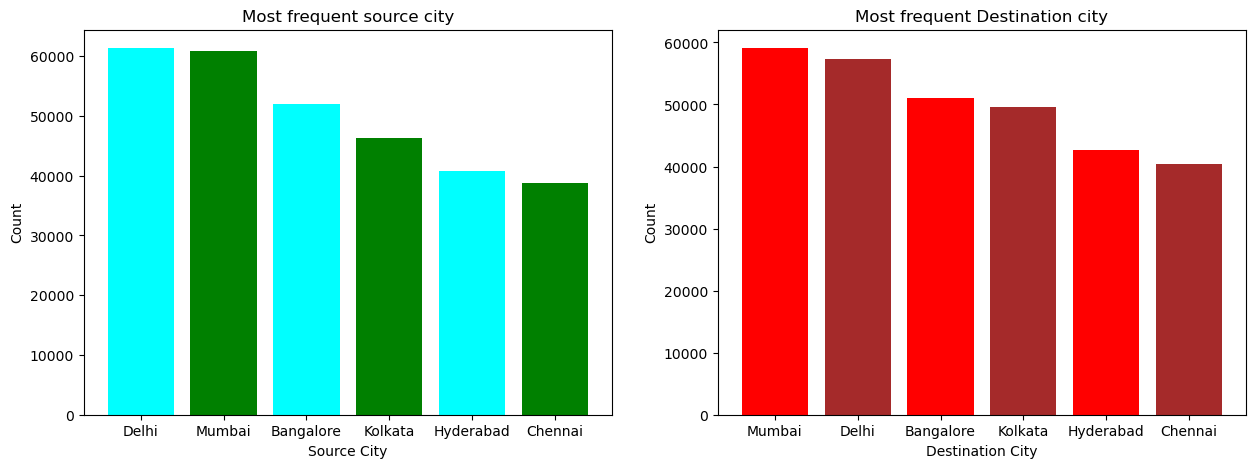

In [21]:
# Ploting the count in bargraph
fig,axs = plt.subplots(1,2,figsize=(15,5))

axs[0].bar(df["source_city"].value_counts().index,df["source_city"].value_counts().values,color=["cyan","green"])
axs[0].set_title("Most frequent source city")
axs[0].set_xlabel("Source City")
axs[0].set_ylabel("Count")

axs[1].bar(df["destination_city"].value_counts().index,df["destination_city"].value_counts().values,color=["red","brown"])
axs[1].set_title("Most frequent Destination city")
axs[1].set_xlabel("Destination City")
axs[1].set_ylabel("Count")
plt.show()

### Q4. Does price varies with airlines

In [22]:
# Grouping each airline to get the mean of the data
df.groupby("airline")["price"].mean().sort_values()

airline
AirAsia       4091.072742
Indigo        5324.216303
GO_FIRST      5652.007595
SpiceJet      6179.278881
Air_India    23507.019112
Vistara      30396.536302
Name: price, dtype: float64

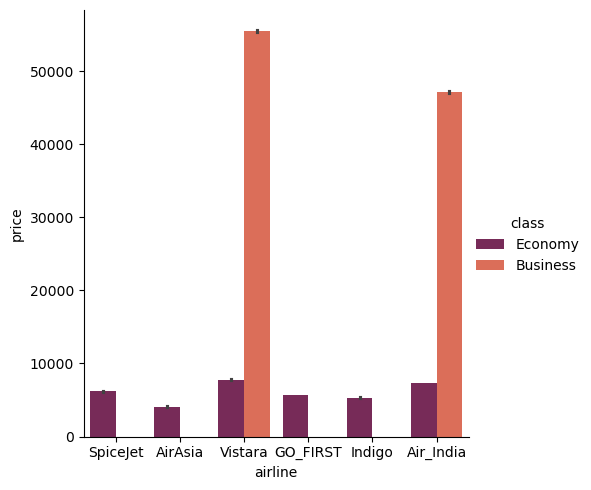

In [23]:
# Drawing a catagorical plot to show each airline mean price

sns.catplot(x = "airline",y="price",kind="bar",data=df,palette='rocket',hue="class")
plt.show()

### Q5. Does tickets price change based on the arival and departure time?

In [24]:
# Getting mean of price based on Departure time
df.groupby("departure_time")["price"].mean().sort_values()

departure_time
Late_Night        9295.299387
Afternoon        18179.203331
Early_Morning    20370.676718
Evening          21232.361894
Morning          21630.760254
Night            23062.146808
Name: price, dtype: float64

In [25]:
# Getting mean of price based on Arrival time
df.groupby("arrival_time")["price"].mean().sort_values()

arrival_time
Late_Night       11284.906078
Early_Morning    14993.139521
Afternoon        18494.598993
Night            21586.758341
Morning          22231.076098
Evening          23044.371615
Name: price, dtype: float64

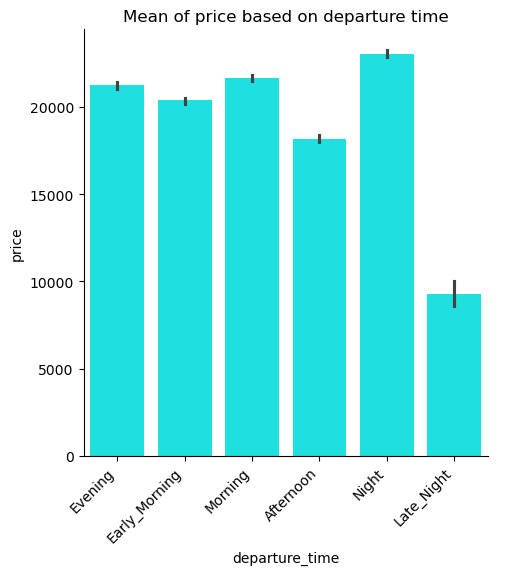

In [26]:
# ploting a catagorical chart for the mean of the prices for departure time

sns.catplot(x="departure_time",y="price",kind="bar",data=df,color="cyan")
plt.xticks(rotation=45,ha="right")
plt.title("Mean of price based on departure time")
plt.show()

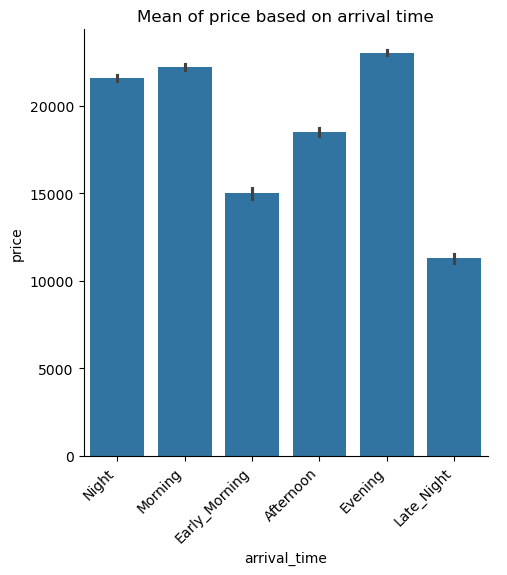

In [27]:
# ploting for arrival time
sns.catplot(x="arrival_time",y="price",kind="bar",data=df)
plt.xticks(rotation=45,ha="right")
plt.title("Mean of price based on arrival time")
plt.show()

### Q6. How the price changes with change in source and destination?

In [28]:
# Checking the mean ticket price for each source city
df.groupby("source_city")["price"].mean().sort_values()

source_city
Delhi        18951.326639
Hyderabad    20155.623879
Bangalore    21469.460575
Mumbai       21483.818839
Kolkata      21746.235679
Chennai      21995.339871
Name: price, dtype: float64

In [29]:
# Checking the mean ticket price for each destination city
df.groupby("destination_city")["price"].mean().sort_values()

destination_city
Delhi        18436.767870
Hyderabad    20427.661284
Mumbai       21372.529469
Bangalore    21593.955784
Chennai      21953.323969
Kolkata      21959.557556
Name: price, dtype: float64

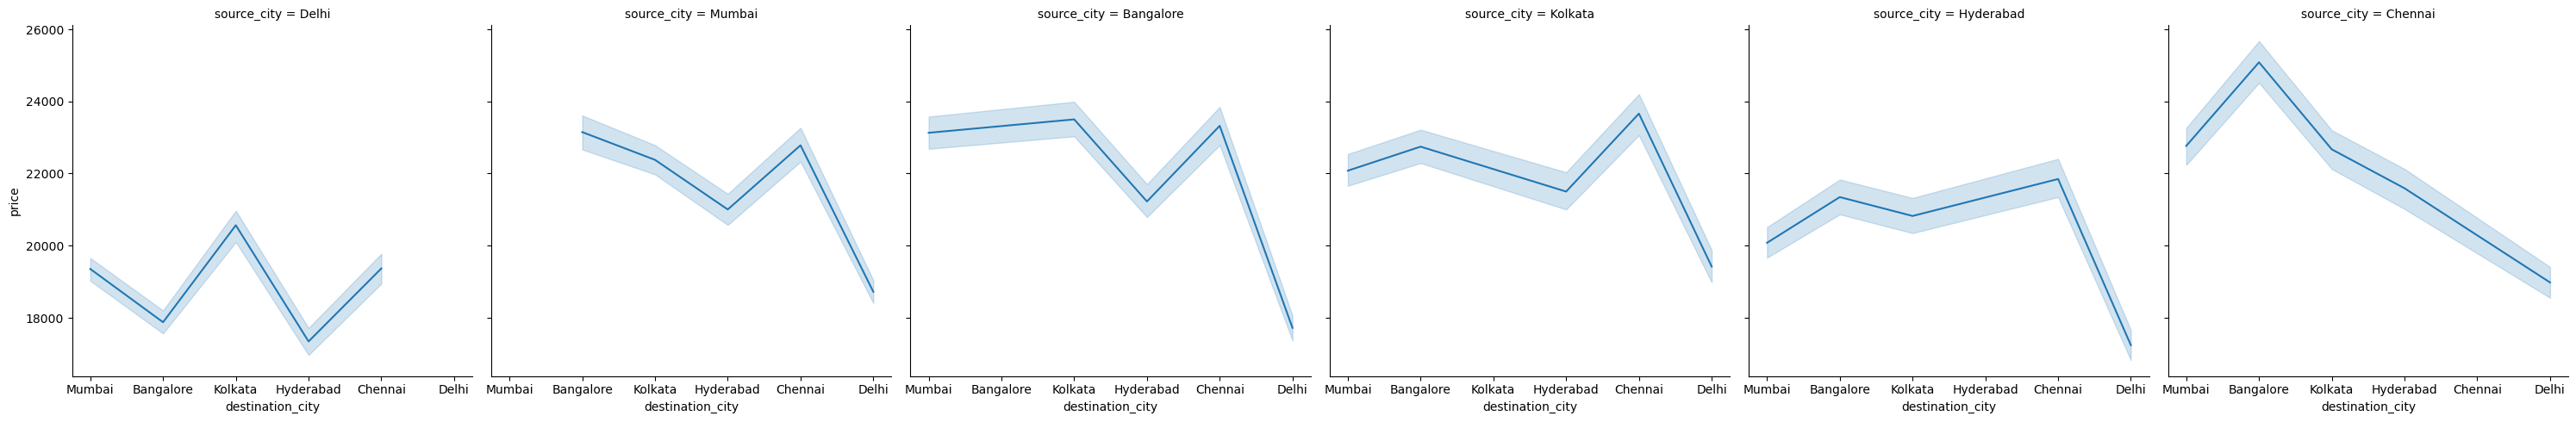

In [30]:
# Drawing a relation plot using the seaborn library
# comaprision of mean price between each source city

sns.relplot(x="destination_city",y="price",data=df,col="source_city",kind="line")
plt.show()

### Q7. How are tickets price affected when tickets are brought in just 1 or 2 days before departure?

In [31]:
df.groupby("days_left")["price"].mean()

days_left
1     21591.867151
2     30211.299801
3     28976.083569
4     25730.905653
5     26679.773368
6     24856.493902
7     25588.367351
8     24895.883995
9     25726.246072
10    25572.819134
11    22990.656070
12    22505.803322
13    22498.885384
14    22678.002363
15    21952.540852
16    20503.546237
17    20386.353949
18    19987.445168
19    19507.677375
20    19699.983390
21    19430.494058
22    19590.667385
23    19840.913451
24    19803.908896
25    19571.641791
26    19238.290278
27    19950.866195
28    19534.986047
29    19744.653119
30    19567.580834
31    19392.706612
32    19258.135308
33    19306.271739
34    19562.008266
35    19255.652996
36    19517.688444
37    19506.306516
38    19734.912316
39    19262.095556
40    19144.972439
41    19347.440460
42    19154.261659
43    19340.528894
44    19049.080174
45    19199.876307
46    19305.351623
47    18553.272038
48    18998.126851
49    18992.971888
Name: price, dtype: float64

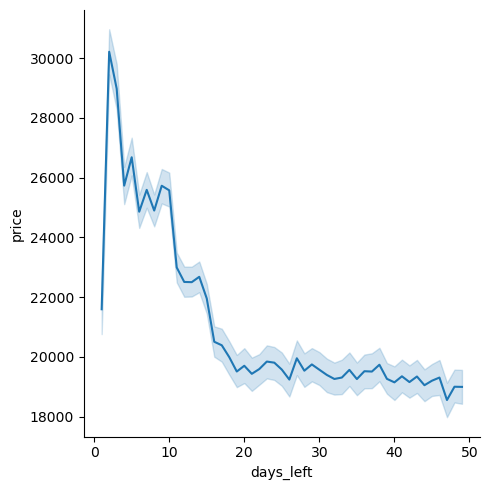

In [32]:
# Drawing a relation plot for mean tickets price booked before 1 or 2 days 
sns.relplot(x="days_left",y="price",kind="line",data=df)
plt.show()

### Q8. How the ticket price vary between economy and business class?

In [ ]:
# Checking mean price for classes 

df.groupby("class")["price"].mean().sort_values(ascending=False)

class
Business    52540.081124
Economy      6572.342383
Name: price, dtype: float64

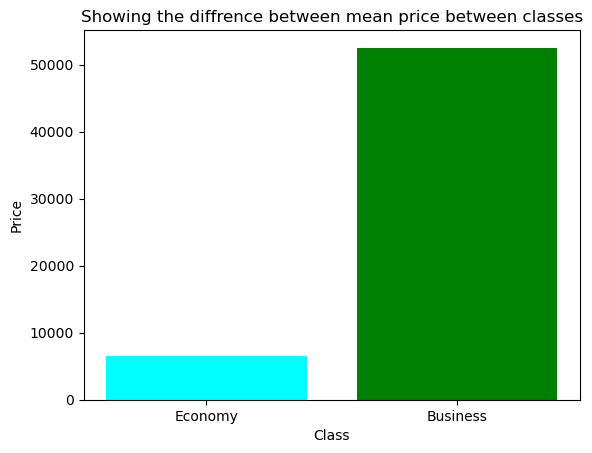

In [34]:
# ploting a bar graph to show the differenc between the mean price of the classes

plt.bar(df.groupby("class")["price"].mean().sort_values().index,df.groupby("class")["price"].mean().sort_values().values,color=["cyan","green"])
plt.title("Showing the diffrence between mean price between classes")
plt.xlabel("Class")
plt.ylabel("Price")
plt.show()

### Q9. What will be the average price for a vistara arline for a flight from delhi to hyderabad in business class?

In [35]:
avg_price = df[(df["airline"]=="Vistara")&(df["source_city"]=="Delhi")&(df["destination_city"]=="Hyderabad") & (df["class"]=="Business")]["price"].mean()
print(f"The average price of vistara airline form delhi to hyderabad in business class is: {avg_price}")

The average price of vistara airline form delhi to hyderabad in business class is: 47939.840361445786


### Loading the data set in Postgrel SQL

- Uploaded the dataset on postgrel sql for making power bi dashboard

In [36]:
from sqlalchemy import create_engine


username = "postgres"
password = "020705"
host = "localhost"
port = "5432"
database = "Airlines"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

table_name = "Airline"
df.to_sql(table_name,engine,if_exists="replace",index=False)
print(f"Data Succefully loaded into table {table_name} in database {database}")

Data Succefully loaded into table Airline in database Airlines
